In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


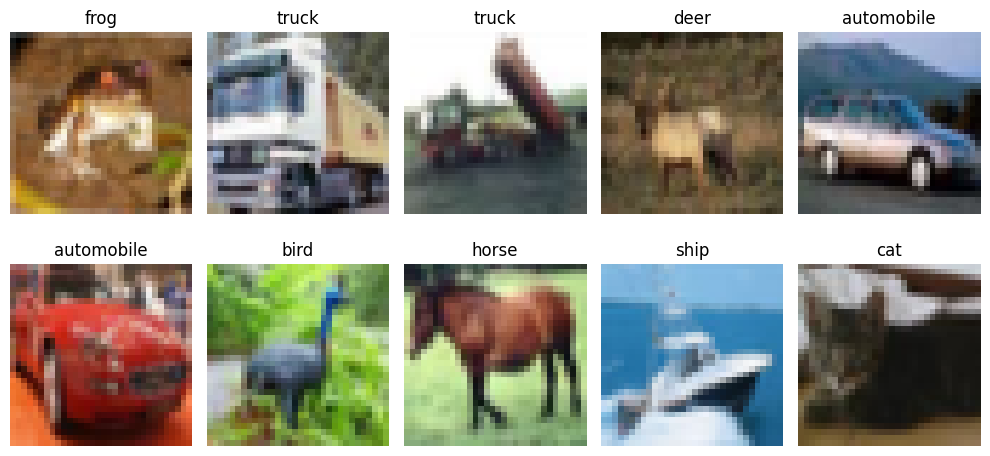

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.2641 - loss: 2.0058 - val_accuracy: 0.3372 - val_loss: 1.8415
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3102 - loss: 1.8940 - val_accuracy: 0.3498 - val_loss: 1.7947
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3336 - loss: 1.8247 - val_accuracy: 0.3722 - val_loss: 1.7690
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3428 - loss: 1.8028 - val_accuracy: 0.3688 - val_loss: 1.7639
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3534 - loss: 1.7748 - val_accuracy: 0.4014 - val_loss: 1.7174
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3646 - loss: 1.7467 - val_accuracy: 0.4100 - val_loss: 1.6981
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3687 - loss: 1.7349 - val_accuracy: 0.4012 - val_loss: 1.7142
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3728 - loss: 1.7233 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4252 - loss: 1.6379
ANN Test Accuracy: 0.4251999855041504


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 122ms/step - accuracy: 0.4653 - loss: 1.4972 - val_accuracy: 0.4948 - val_loss: 1.4479
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6064 - loss: 1.1218 - val_accuracy: 0.5988 - val_loss: 1.1354
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.6728 - loss: 0.9402 - val_accuracy: 0.6332 - val_loss: 1.0722
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 122ms/step - accuracy: 0.7150 - loss: 0.8247 - val_accuracy: 0.6150 - val_loss: 1.1148
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.7430 - loss: 0.7384 - val_accuracy: 0.7238 - val_loss: 0.8108
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.7713 - loss: 0.6592 - val_accuracy: 0.6842 - val_loss: 0.9603
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.7927 - loss: 0.5886 - val_accuracy: 0.6726 - val_loss: 1.0109
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 120ms/step - accuracy: 0.8141 - los

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7098 - loss: 0.9426
CNN Test Accuracy: 0.7098000049591064


## 📈 Compare Learning Curves

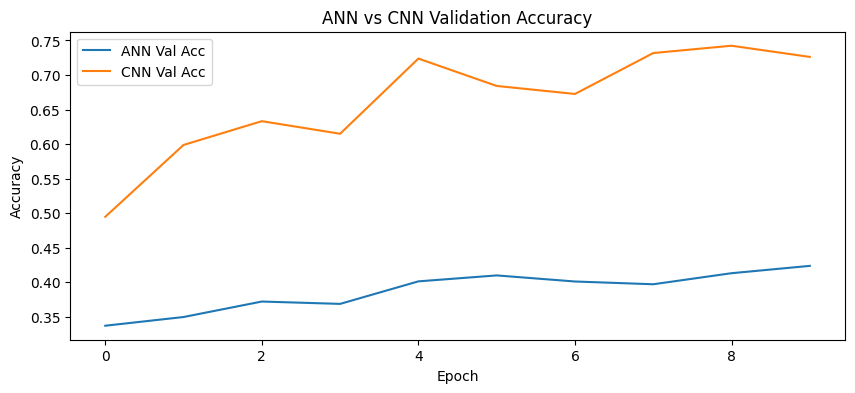

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [13]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 51ms/step - accuracy: 0.3870 - loss: 1.6780 - val_accuracy: 0.5004 - val_loss: 1.4067
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.4870 - loss: 1.4340 - val_accuracy: 0.5570 - val_loss: 1.2419
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5240 - loss: 1.3376 - val_accuracy: 0.5662 - val_loss: 1.2236
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5444 - loss: 1.2839 - val_accuracy: 0.5822 - val_loss: 1.1806
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.5580 - loss: 1.2497 - val_accuracy: 0.5928 - val_loss: 1.1551
Epoch 6/10


KeyboardInterrupt: 

# 📊 Final Comparison Table

In [14]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4252
1,CNN,0.7098


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [ ]:
print("--- Initializing Upgraded Student Model ---")

# Task 5: Data Augmentation Configuration
custom_augmentor = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
], name="Augmentation_Layer")

# Task 1 & 2: Increased CNN Filters (64->128) and Expanded Dense Layout (512)
custom_student_net = models.Sequential([
    custom_augmentor,

    layers.Conv2D(64, (3, 3), activation='leaky_relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='leaky_relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name="Upgraded_Network")

custom_student_net.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Early Stopping to prevent overfitting
stringent_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Task 3: Train for up to 20 epochs using an altered batch size
print("Initiating training sequence...")
independent_history = custom_student_net.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=128,
    callbacks=[stringent_stopping]
)

final_task_loss, final_task_acc = custom_student_net.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nExecution Complete. Upgraded Model Test Accuracy: {final_task_acc:.4f}")

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**